In [99]:
import pandas as pd

In [100]:
df=pd.read_csv("netflix_customer_churn.csv")

In [101]:
df.head(4)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror


In [102]:
df.shape

(5000, 14)

In [103]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [104]:
df = df.drop(columns=['customer_id'])

In [105]:
from matplotlib import pyplot as plt

In [106]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [107]:
df.dtypes

age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [108]:
df.isnull().sum()

age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [109]:
df.head(4)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror


In [110]:
df['subscription_type'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [111]:
df.dtypes

age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [112]:
df['region'].unique()

array(['Africa', 'Europe', 'Asia', 'Oceania', 'South America',
       'North America'], dtype=object)

| Encoding Technique     | When to Use                                                      | Example Data                          | Encoded Output Example                            |
| ---------------------- | ---------------------------------------------------------------- | ------------------------------------- | ------------------------------------------------- |
| **Label Encoding**     | When data has **order (ordinal)** and simple mapping is fine     | Size: Small, Medium, Large            | Small → 0, Medium → 1, Large → 2                  |
| **Ordinal Encoding**   | When data has **clear ranking** and you want control over values | Plan: Basic, Standard, Premium        | Basic → 0, Standard → 1, Premium → 2              |
| **One-Hot Encoding**   | When data has **no order (nominal)** and few categories          | City: Pune, Mumbai, Delhi             | Pune → [1,0,0], Mumbai → [0,1,0], Delhi → [0,0,1] |
| **Binary Encoding**    | When **many categories** and want fewer columns                  | Category: A, B, C, D                  | A → 00, B → 01, C → 10, D → 11                    |
| **Frequency Encoding** | When category importance depends on **count**                    | City frequency: Mumbai(100), Pune(50) | Mumbai → 100, Pune → 50                           |
| **Target Encoding**    | When large data & want encoding based on **target variable**     | City vs Salary                        | Mumbai → 50000, Pune → 30000                      |
| **Hash Encoding**      | When **very high cardinality** and memory matters                | User IDs                              | ID → hashed number (fixed columns)                |


In [113]:
df['gender'].unique()

array(['Other', 'Female', 'Male'], dtype=object)

In [114]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()

lb.fit_transform(df['gender'])

array([2, 2, 0, ..., 1, 0, 1])

In [115]:

df['gender'] = lb.fit_transform(df['gender'])
df['subscription_type'] = lb.fit_transform(df['subscription_type'])

In [116]:
df.head(4)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,2,2,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,0,2,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,2,1,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror


In [117]:
lb = LabelEncoder()
df['subscription_type'] = lb.fit_transform(df['subscription_type'])

print(lb.classes_)
lb.classes_

[0 1 2]


array([0, 1, 2])

In [118]:
mapping = dict(zip(lb.classes_, lb.transform(lb.classes_)))
print(mapping)

{0: 0, 1: 1, 2: 2}


In [119]:
df.dtypes

age                         int64
gender                      int64
subscription_type           int64
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [120]:
df['region'].unique()

array(['Africa', 'Europe', 'Asia', 'Oceania', 'South America',
       'North America'], dtype=object)

In [121]:
from sklearn.preprocessing import OneHotEncoder

on = OneHotEncoder(sparse_output=False)

encoded = on.fit_transform(df[['region']])


In [122]:
df['region']=encoded
df['payment_method']=on.fit_transform(df[['payment_method']])
df['device']=on.fit_transform(df[['device']])
df['favorite_genre']=on.fit_transform(df[['favorite_genre']])

In [123]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,1.0,0.0,8.99,1,0.0,1,0.49,1.0
1,47,2,2,0.70,19,0.0,0.0,13.99,1,0.0,5,0.03,0.0
2,27,0,2,16.32,10,0.0,0.0,13.99,0,0.0,2,1.48,0.0
3,53,2,1,4.51,12,0.0,0.0,17.99,1,0.0,2,0.35,0.0
4,56,2,2,1.89,13,1.0,0.0,13.99,1,0.0,2,0.13,1.0


In [124]:
df['payment_method'].unique()

array([0., 1.])

In [125]:
df['device'].unique()

array([0., 1.])

In [126]:
df['favorite_genre'].unique()

array([1., 0.])

In [127]:
df.dtypes

age                         int64
gender                      int64
subscription_type           int64
watch_hours               float64
last_login_days             int64
region                    float64
device                    float64
monthly_fee               float64
churned                     int64
payment_method            float64
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre            float64
dtype: object

In [128]:
df[:10]

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,1.0,0.0,8.99,1,0.0,1,0.49,1.0
1,47,2,2,0.70,19,0.0,0.0,13.99,1,0.0,5,0.03,0.0
2,27,0,2,16.32,10,0.0,0.0,13.99,0,0.0,2,1.48,0.0
3,53,2,1,4.51,12,0.0,0.0,17.99,1,0.0,2,0.35,0.0
4,56,2,2,1.89,13,1.0,0.0,13.99,1,0.0,2,0.13,1.0
5,58,0,2,13.80,26,0.0,0.0,13.99,0,0.0,3,0.51,1.0
6,48,2,0,13.83,20,0.0,0.0,8.99,0,0.0,5,0.66,0.0
7,51,1,0,14.30,56,0.0,0.0,8.99,1,0.0,1,0.25,1.0
8,45,2,0,9.98,10,0.0,0.0,8.99,0,0.0,3,0.91,0.0
9,32,2,1,2.22,34,0.0,0.0,17.99,1,0.0,1,0.06,0.0


In [129]:
last_login_days_churn_No=df[df.churned==0].last_login_days 
last_login_days_churn_No[:5]

2     10
5     26
6     20
8     10
10    36
Name: last_login_days, dtype: int64

In [130]:
last_login_days_churn_yes=df[df.churned==1].last_login_days 
last_login_days_churn_yes[:5]

0    29
1    19
3    12
4    13
7    56
Name: last_login_days, dtype: int64

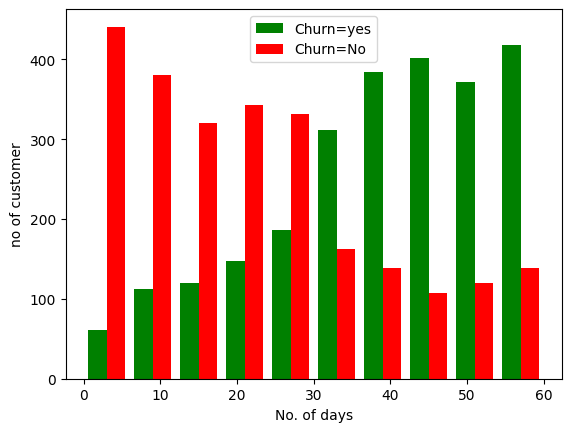

In [131]:
from matplotlib import pyplot as plt

plt.xlabel("No. of days")
plt.ylabel("no of customer")
plt.hist([last_login_days_churn_yes,last_login_days_churn_No],color=['green','red'],label=['Churn=yes','Churn=No'])
plt.legend()

Users who haven’t logged in for a long time (50–60 days) → very likely to churn
Users who logged in recently (0–10 days) → less likely to churn

2. here i have missunderstood the column it says last lgiend that means he has not loggined his acc for the past those daya 

In [132]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [133]:
watch_hours_No=df[df.churned==0].watch_hours
watch_hours_No[:5]

2     16.32
5     13.80
6     13.83
8      9.98
10    15.42
Name: watch_hours, dtype: float64

In [134]:
watch_hours_Yes=df[df.churned==1].watch_hours
watch_hours_Yes[:5]

0    14.73
1     0.70
3     4.51
4     1.89
7    14.30
Name: watch_hours, dtype: float64

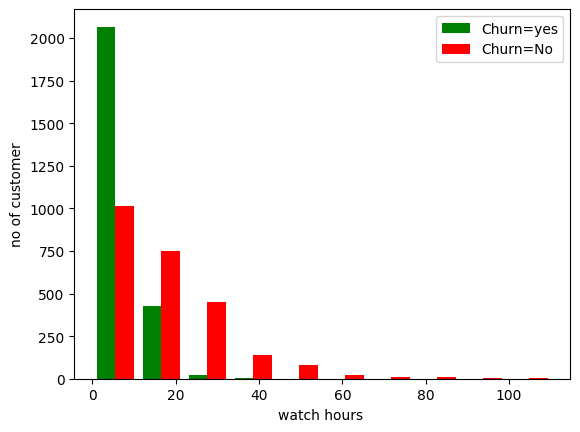

In [135]:
plt.xlabel("watch hours ")
plt.ylabel("no of customer")
plt.hist([watch_hours_Yes,watch_hours_No],color=['green','red'],label=['Churn=yes','Churn=No'])
plt.legend()

In [136]:
df['device'].unique()

array([0., 1.])

In [137]:
monthly_fee_no=df[df.churned==0].monthly_fee
monthly_fee_yes=df[df.churned==1].monthly_fee

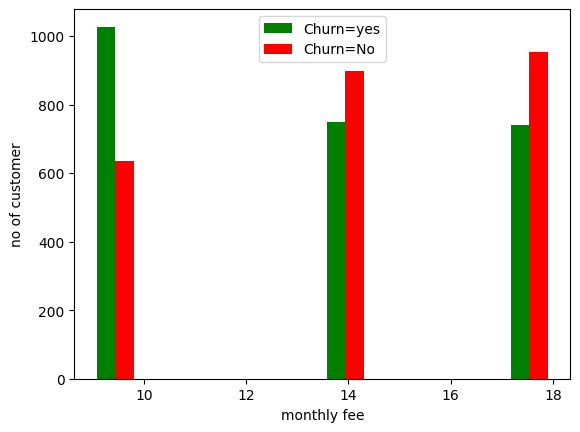

In [138]:
plt.xlabel("monthly fee")
plt.ylabel("no of customer")
plt.hist([monthly_fee_yes,monthly_fee_no],color=['green','red'],label=['Churn=yes','Churn=No'])
plt.legend()

In [139]:
#here the conlusion is comming out is that the the people with more 16 are not likely to churn the company 

At low monthly fee (~10) →
Green (churn yes) is higher than red → more people are churning
At higher monthly fees (~14–18) →
Red (churn no) is higher than green → fewer people are churning

In [140]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,1.0,0.0,8.99,1,0.0,1,0.49,1.0
1,47,2,2,0.70,19,0.0,0.0,13.99,1,0.0,5,0.03,0.0
2,27,0,2,16.32,10,0.0,0.0,13.99,0,0.0,2,1.48,0.0
3,53,2,1,4.51,12,0.0,0.0,17.99,1,0.0,2,0.35,0.0
4,56,2,2,1.89,13,1.0,0.0,13.99,1,0.0,2,0.13,1.0


In [141]:
target=df['churned']
target.head()

0    1
1    1
2    0
3    1
4    1
Name: churned, dtype: int64

In [142]:
df1=df.drop(columns='churned')

In [73]:
df1.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,1.0,0.0,8.99,0.0,1,0.49,1.0
1,47,2,2,0.70,19,0.0,0.0,13.99,0.0,5,0.03,0.0
2,27,0,2,16.32,10,0.0,0.0,13.99,0.0,2,1.48,0.0
3,53,2,1,4.51,12,0.0,0.0,17.99,0.0,2,0.35,0.0
4,56,2,2,1.89,13,1.0,0.0,13.99,0.0,2,0.13,1.0


In [143]:
from sklearn.model_selection import train_test_split

X_train , x_test , y_train , y_test = train_test_split(df1,target,test_size=0.2,random_state=42)

In [144]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [145]:
df1['age']=scaler.fit_transform(df1[['age']])
df1['watch_hours']=scaler.fit_transform(df1[['watch_hours']])
df1['last_login_days']=scaler.fit_transform(df1[['last_login_days']])
df1['monthly_fee']=scaler.fit_transform(df1[['monthly_fee']])


In [146]:
df1.head(2)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,0.461471,2,0,0.256425,-0.062152,1.0,0.0,-1.271341,0.0,1,0.49,1.0
1,0.203399,2,2,-0.911432,-0.632462,0.0,0.0,0.083051,0.0,5,0.03,0.0


In [148]:
X_train.shape

(4000, 12)

In [150]:
y_test.shape

(1000,)

In [152]:
x_test.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
1501,39,2,0,9.96,22,0.0,0.0,8.99,0.0,5,0.43,0.0
2586,18,0,2,0.25,37,1.0,0.0,13.99,0.0,5,0.01,0.0
2653,19,0,2,8.54,6,1.0,0.0,13.99,1.0,3,1.22,0.0
1055,34,1,1,13.49,51,0.0,0.0,17.99,0.0,1,0.26,0.0
705,29,1,0,24.18,59,1.0,0.0,8.99,1.0,1,0.40,0.0


![image.png](attachment:abd7d779-3e22-4bba-9566-382b9f9e9c22.png)

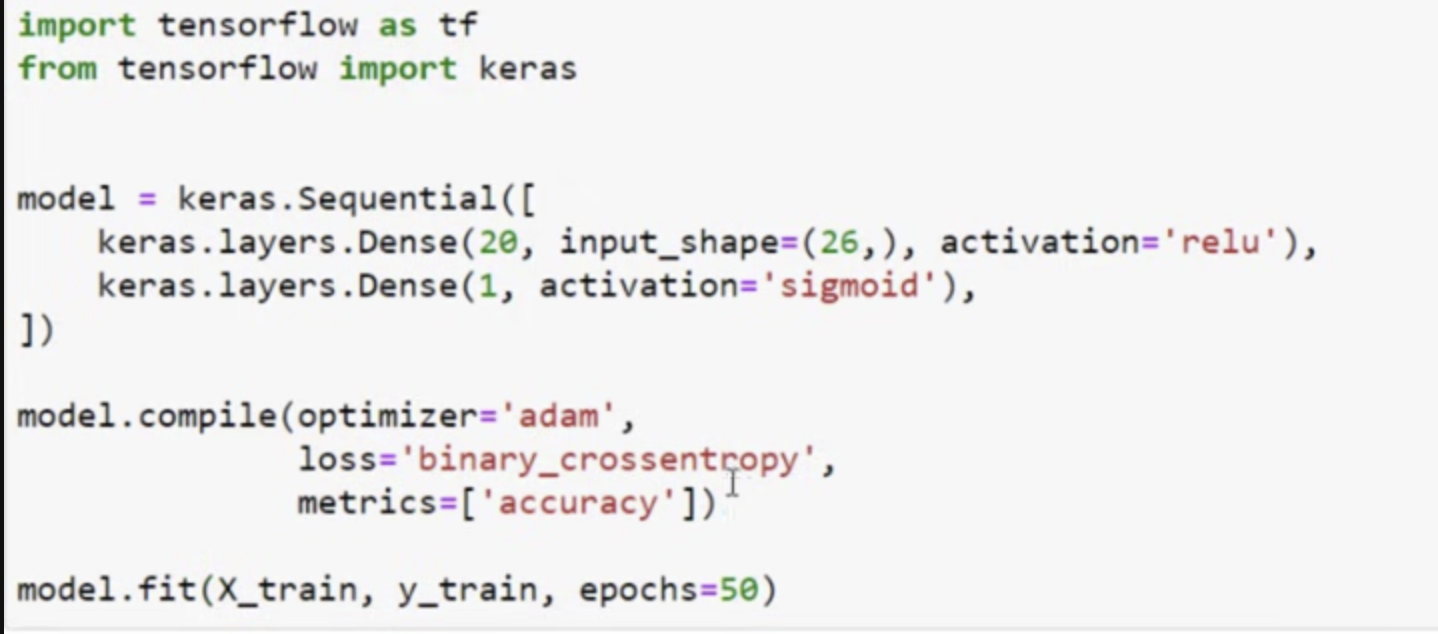

In [154]:
len(X_train.columns)

12

In [153]:
import tensorflow as tf
from tensorflow import keras

In [160]:
model=keras.Sequential(
    [
        keras.layers.Dense(32,input_shape=(12,),activation ='relu'),
        keras.layers.Dense(2,activation ='sigmoid'),
        keras.layers.Dense(1,activation ='sigmoid'),
    ]
)

model.compile(optimizer='adam',
             loss='binary_crossentropy'
              metrics=['accuracy']
             )

SyntaxError: invalid syntax (325293823.py, line 11)

In [161]:
model = keras.Sequential([
    keras.layers.Dense(32, input_shape=(12,), activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-21 02:03:10.564204: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-21 02:03:10.564445: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-21 02:03:10.565228: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-21 02:03:10.565518: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-21 02:03:10.566241: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fa

In [162]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10


2026-04-21 02:03:59.742660: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7929 - loss: 0.5048
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8582 - loss: 0.3333
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8655 - loss: 0.2976
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8618 - loss: 0.3060
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8641 - loss: 0.3010
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8687 - loss: 0.2806
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8676 - loss: 0.3041
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8587 - loss: 0.3068
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8737 - loss: 0.2831
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8676 - loss: 0.2848


In [163]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8664 - loss: 0.2892
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8649 - loss: 0.3039
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8792 - loss: 0.2728
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8713 - loss: 0.2846
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8649 - loss: 0.2965
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8819 - loss: 0.2668
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8623 - loss: 0.3011
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8653 - loss: 0.2884
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8670 - loss: 0.2981
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8654 - loss: 0.3111
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8565 - loss: 0.3102
Epoch 12/100
125/125 ━━━━━━━━━━━━━━━━━━━

In [164]:
model1 = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(12,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [165]:
model1.fit(X_train,y_train,epochs=100)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6098 - loss: 1.5828
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8703 - loss: 0.2887
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8683 - loss: 0.3020
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8464 - loss: 0.3122
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8622 - loss: 0.2954
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8663 - loss: 0.2944
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8628 - loss: 0.2959
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8692 - loss: 0.2886
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8583 - loss: 0.3055
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8743 - loss: 0.2783
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8690 - loss: 0.2850
Epoch 12/100
125/125 ━━━━━━━━━

In [167]:
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [172]:
y_pred

array([[0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
    

In [171]:
y_pred_1 = model1.predict(x_test)
y_pred_1 = (y_pred > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [173]:
y_pred_1

array([[0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
    

In [174]:
y_test

1501    0
2586    1
2653    0
1055    1
705     1
       ..
4711    0
2313    1
3214    0
2732    0
1926    0
Name: churned, Length: 1000, dtype: int64

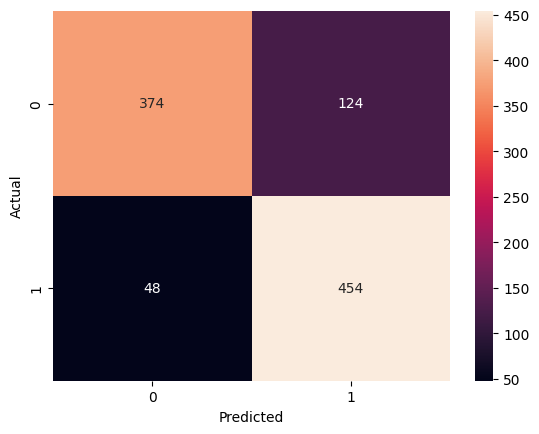

In [175]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [179]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.828


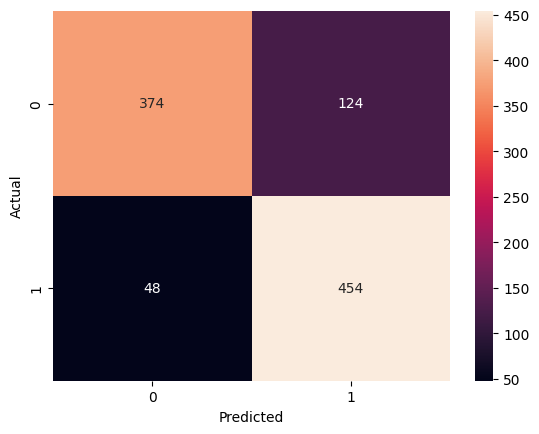

In [176]:
cm = confusion_matrix(y_test, y_pred_1)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [180]:
accuracy = accuracy_score(y_test, y_pred_1)
print("Accuracy:", accuracy)

Accuracy: 0.828


In [181]:
model.save("netflix_churn_model.h5")

In [183]:
import joblib

joblib.dump(scaler, "netflix_scaler.pkl")

['netflix_scaler.pkl']